In [1]:
import pandas as pd
import pybedtools

In [2]:
mega_ctrl_loops_df = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_rbp1.bedpe", sep="\t", header=None)
mega_ctrl_loops_df.columns = ["chr1", "start1", "end1", "chr2", "start2", "end2"]
mega_ctrl_loops_df

,chr1,start1,end1,chr2,start2,end2
0,chr1,3910000,3915000,chr1,4065000,4070000
1,chr1,3910000,3915000,chr1,4155000,4160000
2,chr1,5502500,5507500,chr1,5622500,5627500
3,chr1,5502500,5507500,chr1,5732500,5737500
4,chr1,5632500,5637500,chr1,5752500,5757500
...,...,...,...,...,...,...
16594,chrY,11292500,11297500,chrY,11722500,11727500
16595,chrY,11522500,11527500,chrY,11712500,11717500
16596,chrY,11525000,11530000,chrY,11680000,11685000
16597,chrY,11530000,11535000,chrY,11760000,11765000


In [3]:
anchor1_mega_ctrl = pybedtools.BedTool.from_dataframe(mega_ctrl_loops_df[["chr1", "start1", "end1"]])
anchor2_mega_ctrl = pybedtools.BedTool.from_dataframe(mega_ctrl_loops_df[["chr2", "start2", "end2"]])

In [4]:
anchor1_mega_ctrl

<BedTool(/tmp/pybedtools.gl020zq5.tmp)>

In [5]:
tads = pybedtools.BedTool("/usr/users/papantonis1/RobusTAD/final_tad_rbp1_hq.bed").cut([0, 1, 2])

In [6]:
anchor1_tad = anchor1_mega_ctrl.intersect(tads, wa=True, wb=True).to_dataframe(names=["chr", "start", "end", "tad_chr", "tad_start", "tad_end"])
anchor2_tad = anchor2_mega_ctrl.intersect(tads, wa=True, wb=True).to_dataframe(names=["chr", "start", "end", "tad_chr", "tad_start", "tad_end"])

In [7]:
anchor1_tad.head()

,chr,start,end,tad_chr,tad_start,tad_end
0,chr1,3910000,3915000,chr1,3900000,4800000
1,chr1,3910000,3915000,chr1,3900000,4800000
2,chr1,5632500,5637500,chr1,5635000,5745000
3,chr1,5632500,5637500,chr1,5510000,5745000
4,chr1,6722500,6727500,chr1,6720000,6780000


In [8]:
# merge back to loop df
# Clean and rename anchor1 intersection columns
# Deduplicate anchor1 overlaps ## pd.merge cartesian join , combinatorial
anchor1_clean = anchor1_tad.drop_duplicates(subset=["chr", "start", "end"])[
    ["chr", "start", "end", "tad_start", "tad_end"]
].rename(columns={
    "chr": "chr_anchor1", 
    "start": "start_anchor1", 
    "end": "end_anchor1", 
    "tad_start": "tad_start_anchor1", 
    "tad_end": "tad_end_anchor1"
})

# Same for anchor2
anchor2_clean = anchor2_tad.drop_duplicates(subset=["chr", "start", "end"])[
    ["chr", "start", "end", "tad_start", "tad_end"]
].rename(columns={
    "chr": "chr_anchor2", 
    "start": "start_anchor2", 
    "end": "end_anchor2", 
    "tad_start": "tad_start_anchor2", 
    "tad_end": "tad_end_anchor2"
})

mega_ctrl_loops_df = mega_ctrl_loops_df.merge(
    anchor1_clean, 
    left_on=["chr1", "start1", "end1"], 
    right_on=["chr_anchor1", "start_anchor1", "end_anchor1"], 
    how="left"
)
mega_ctrl_loops_df = mega_ctrl_loops_df.merge(
    anchor2_clean, 
    left_on=["chr2", "start2", "end2"], 
    right_on=["chr_anchor2", "start_anchor2", "end_anchor2"], 
    how="left"
)
mega_ctrl_loops_df

,chr1,start1,end1,chr2,start2,end2,chr_anchor1,start_anchor1,end_anchor1,tad_start_anchor1,tad_end_anchor1,chr_anchor2,start_anchor2,end_anchor2,tad_start_anchor2,tad_end_anchor2
0,chr1,3910000,3915000,chr1,4065000,4070000,chr1,3910000.0,3915000.0,3900000.0,4800000.0,chr1,4065000.0,4070000.0,3900000.0,4800000.0
1,chr1,3910000,3915000,chr1,4155000,4160000,chr1,3910000.0,3915000.0,3900000.0,4800000.0,chr1,4155000.0,4160000.0,3900000.0,4800000.0
2,chr1,5502500,5507500,chr1,5622500,5627500,NaN,NaN,NaN,NaN,NaN,chr1,5622500.0,5627500.0,5510000.0,5745000.0
3,chr1,5502500,5507500,chr1,5732500,5737500,NaN,NaN,NaN,NaN,NaN,chr1,5732500.0,5737500.0,5635000.0,5745000.0
4,chr1,5632500,5637500,chr1,5752500,5757500,chr1,5632500.0,5637500.0,5635000.0,5745000.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16594,chrY,11292500,11297500,chrY,11722500,11727500,chrY,11292500.0,11297500.0,10645000.0,11540000.0,NaN,NaN,NaN,NaN,NaN
16595,chrY,11522500,11527500,chrY,11712500,11717500,chrY,11522500.0,11527500.0,11335000.0,11540000.0,NaN,NaN,NaN,NaN,NaN
16596,chrY,11525000,11530000,chrY,11680000,11685000,chrY,11525000.0,11530000.0,11335000.0,11540000.0,NaN,NaN,NaN,NaN,NaN
16597,chrY,11530000,11535000,chrY,11760000,11765000,chrY,11530000.0,11535000.0,11335000.0,11540000.0,chrY,11760000.0,11765000.0,11750000.0,12900000.0


In [9]:
mega_ctrl_loops_df = mega_ctrl_loops_df.drop(
    columns=[
        "chr_anchor1", "start_anchor1", "end_anchor1",
        "chr_anchor2", "start_anchor2", "end_anchor2"
    ]
)
mega_ctrl_loops_df

,chr1,start1,end1,chr2,start2,end2,tad_start_anchor1,tad_end_anchor1,tad_start_anchor2,tad_end_anchor2
0,chr1,3910000,3915000,chr1,4065000,4070000,3900000.0,4800000.0,3900000.0,4800000.0
1,chr1,3910000,3915000,chr1,4155000,4160000,3900000.0,4800000.0,3900000.0,4800000.0
2,chr1,5502500,5507500,chr1,5622500,5627500,NaN,NaN,5510000.0,5745000.0
3,chr1,5502500,5507500,chr1,5732500,5737500,NaN,NaN,5635000.0,5745000.0
4,chr1,5632500,5637500,chr1,5752500,5757500,5635000.0,5745000.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
16594,chrY,11292500,11297500,chrY,11722500,11727500,10645000.0,11540000.0,NaN,NaN
16595,chrY,11522500,11527500,chrY,11712500,11717500,11335000.0,11540000.0,NaN,NaN
16596,chrY,11525000,11530000,chrY,11680000,11685000,11335000.0,11540000.0,NaN,NaN
16597,chrY,11530000,11535000,chrY,11760000,11765000,11335000.0,11540000.0,11750000.0,12900000.0


Text(0.5, 1.0, 'Loop Span vs TAD Span')

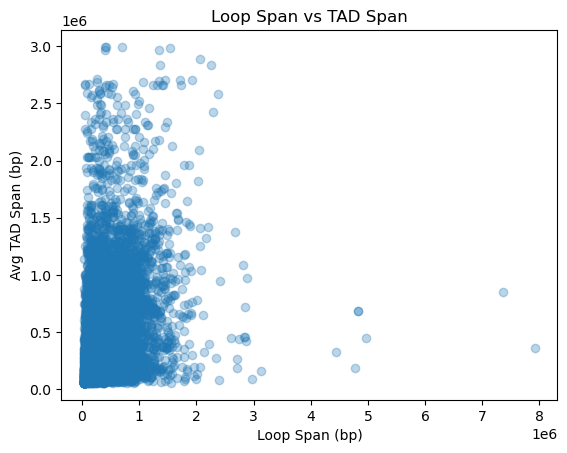

In [10]:
#Scatter Plot - TAD span vs loop span
import matplotlib.pyplot as plt

tad_span_1 = mega_ctrl_loops_df["tad_end_anchor1"] - mega_ctrl_loops_df["tad_start_anchor1"]
tad_span_2 = mega_ctrl_loops_df["tad_end_anchor2"] - mega_ctrl_loops_df["tad_start_anchor2"]
loop_span = mega_ctrl_loops_df["start2"] - mega_ctrl_loops_df["start1"]

plt.scatter(loop_span, (tad_span_1 + tad_span_2) / 2, alpha=0.3)
plt.xlabel("Loop Span (bp)")
plt.ylabel("Avg TAD Span (bp)")
plt.title("Loop Span vs TAD Span")

<Axes: title={'center': 'Loop Class Distribution'}, xlabel='loop_class'>

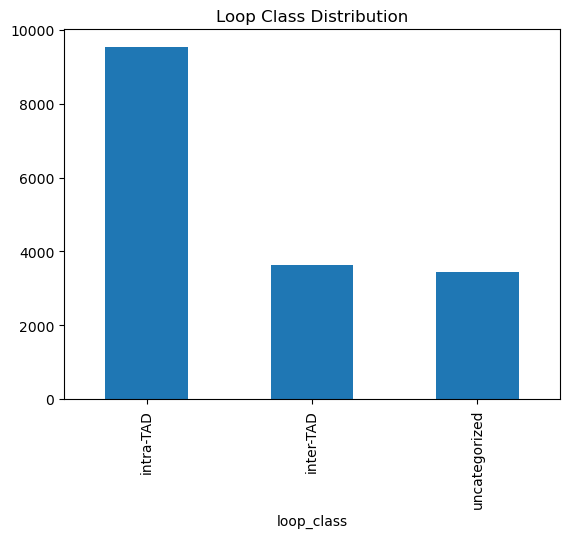

In [11]:
#Classify & Count Intra vs Inter-TAD Loops


def is_anchor_within_tad(anchor_start, anchor_end, tad_start, tad_end):
    return anchor_start >= tad_start and anchor_end <= tad_end

def classify_loop(row):
    try:
        if pd.isna(row["tad_start_anchor1"]) or pd.isna(row["tad_end_anchor1"]) or \
           pd.isna(row["tad_start_anchor2"]) or pd.isna(row["tad_end_anchor2"]):
            return "uncategorized"

        anchor1_in_tad = is_anchor_within_tad(
            row["start1"], row["end1"],
            row["tad_start_anchor1"], row["tad_end_anchor1"]
        )
        anchor2_in_tad = is_anchor_within_tad(
            row["start2"], row["end2"],
            row["tad_start_anchor2"], row["tad_end_anchor2"]
        )
        return "intra-TAD" if anchor1_in_tad and anchor2_in_tad else "inter-TAD"
    except:
        return "uncategorized"

mega_ctrl_loops_df["loop_class"] = mega_ctrl_loops_df.apply(classify_loop, axis=1)

mega_ctrl_loops_df["loop_class"].value_counts().plot(kind="bar", title="Loop Class Distribution")

<Axes: title={'center': 'loop_distance'}, xlabel='loop_class'>

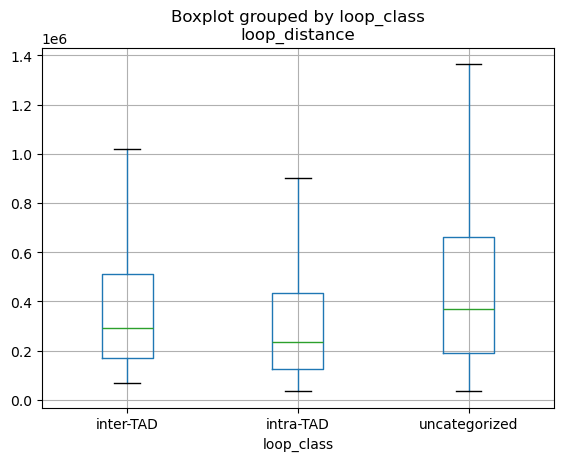

In [12]:
mega_ctrl_loops_df["loop_distance"] = abs(mega_ctrl_loops_df["start2"] - mega_ctrl_loops_df["start1"])
mega_ctrl_loops_df.boxplot(column="loop_distance", by="loop_class", showfliers=False)

<Axes: title={'center': 'loop_distance_kb'}, xlabel='loop_class'>

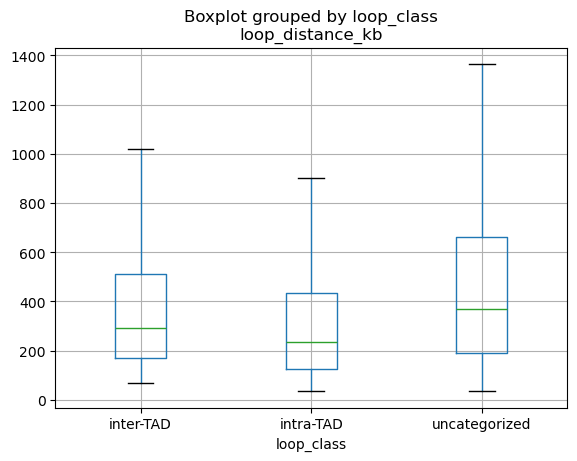

In [13]:
mega_ctrl_loops_df["loop_distance_kb"] = mega_ctrl_loops_df["loop_distance"] / 1000
mega_ctrl_loops_df.boxplot(column="loop_distance_kb", by="loop_class", showfliers=False)

In [14]:
mega_ctrl_loops_df

,chr1,start1,end1,chr2,start2,end2,tad_start_anchor1,tad_end_anchor1,tad_start_anchor2,tad_end_anchor2,loop_class,loop_distance,loop_distance_kb
0,chr1,3910000,3915000,chr1,4065000,4070000,3900000.0,4800000.0,3900000.0,4800000.0,intra-TAD,155000,155.0
1,chr1,3910000,3915000,chr1,4155000,4160000,3900000.0,4800000.0,3900000.0,4800000.0,intra-TAD,245000,245.0
2,chr1,5502500,5507500,chr1,5622500,5627500,NaN,NaN,5510000.0,5745000.0,uncategorized,120000,120.0
3,chr1,5502500,5507500,chr1,5732500,5737500,NaN,NaN,5635000.0,5745000.0,uncategorized,230000,230.0
4,chr1,5632500,5637500,chr1,5752500,5757500,5635000.0,5745000.0,NaN,NaN,uncategorized,120000,120.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16594,chrY,11292500,11297500,chrY,11722500,11727500,10645000.0,11540000.0,NaN,NaN,uncategorized,430000,430.0
16595,chrY,11522500,11527500,chrY,11712500,11717500,11335000.0,11540000.0,NaN,NaN,uncategorized,190000,190.0
16596,chrY,11525000,11530000,chrY,11680000,11685000,11335000.0,11540000.0,NaN,NaN,uncategorized,155000,155.0
16597,chrY,11530000,11535000,chrY,11760000,11765000,11335000.0,11540000.0,11750000.0,12900000.0,intra-TAD,230000,230.0


In [15]:
# Compute TAD sizes
mega_ctrl_loops_df["tad_size_anchor1_kb"] = (mega_ctrl_loops_df["tad_end_anchor1"] - mega_ctrl_loops_df["tad_start_anchor1"]) / 1000
mega_ctrl_loops_df["tad_size_anchor2_kb"] = (mega_ctrl_loops_df["tad_end_anchor2"] - mega_ctrl_loops_df["tad_start_anchor2"]) / 1000

tad_sizes_kb = pd.concat([
    mega_ctrl_loops_df["tad_size_anchor1_kb"],
    mega_ctrl_loops_df["tad_size_anchor2_kb"]
]).dropna()

tad_sizes_kb.describe()

count    28970.000000
mean       386.126855
std        448.133201
min         55.000000
25%        110.000000
50%        210.000000
75%        470.000000
max       2995.000000
dtype: float64

In [16]:
uncategorized_loops = mega_ctrl_loops_df[mega_ctrl_loops_df["loop_class"] == "uncategorized"]
uncategorized_loops["loop_distance_kb"].describe()

count    3432.000000
mean      514.462413
std       543.652566
min        35.000000
25%       190.000000
50%       370.000000
75%       660.000000
max      8310.000000
Name: loop_distance_kb, dtype: float64

In [17]:
intratad_loops = mega_ctrl_loops_df[mega_ctrl_loops_df["loop_class"] == "intra-TAD"]
intratad_loops["loop_distance_kb"].describe()

count    9539.000000
mean      335.610651
std       329.960422
min        35.000000
25%       125.000000
50%       235.000000
75%       435.000000
max      7920.000000
Name: loop_distance_kb, dtype: float64

In [18]:
intertad_loops = mega_ctrl_loops_df[mega_ctrl_loops_df["loop_class"] == "inter-TAD"]
intertad_loops["loop_distance_kb"].describe()

count    3628.000000
mean      392.635061
std       348.149232
min        70.000000
25%       170.000000
50%       290.000000
75%       510.000000
max      7360.000000
Name: loop_distance_kb, dtype: float64

ValueError: Unknown format code 'd' for object of type 'float'

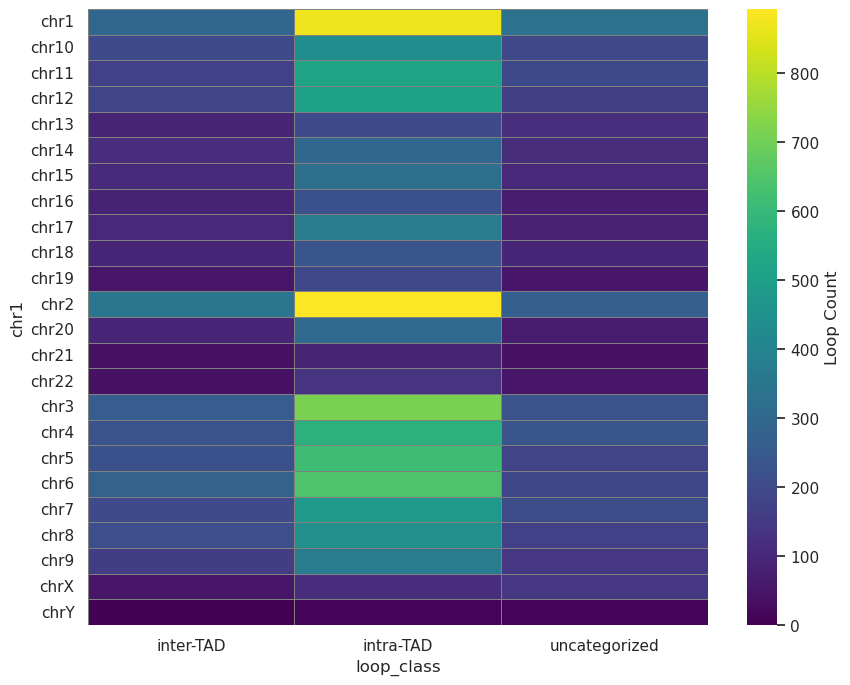

In [19]:
#Heatmap: Loop Class × Chromosome
import matplotlib.pyplot as plt
import seaborn as sns

# Recompute heatmap_data
heatmap_data = mega_ctrl_loops_df.groupby(["chr1", "loop_class"]).size().unstack().fillna(0)

# Sort chromosomes
#chrom_order = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
#heatmap_data = heatmap_data.reindex(chrom_order)

# Plot
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="viridis",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Loop Count"}
)
plt.title("Loop Class Distribution by Chromosome", fontsize=16, weight='bold')
plt.xlabel("Loop Class", fontsize=14)
plt.ylabel("Chromosome", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

ValueError: Unknown format code 'd' for object of type 'float'

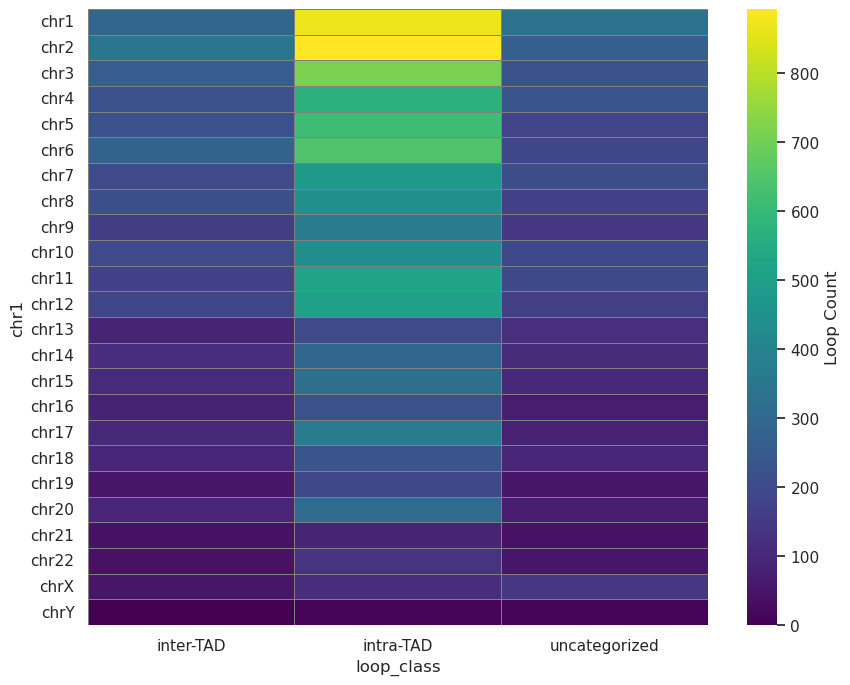

In [ ]:
#Heatmap: Loop Class × Chromosome # ordered
import matplotlib.pyplot as plt
import seaborn as sns

# Recompute heatmap_data
heatmap_data = mega_ctrl_loops_df.groupby(["chr1", "loop_class"]).size().unstack().fillna(0)

# Sort chromosomes
chrom_order = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]
heatmap_data = heatmap_data.reindex(chrom_order)

# Plot
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="viridis",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Loop Count"}
)
plt.title("Loop Class Distribution by Chromosome", fontsize=16, weight='bold')
plt.xlabel("Loop Class", fontsize=14)
plt.ylabel("Chromosome", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

---

In [20]:
print(mega_ctrl_loops_df["loop_class"].value_counts()) #using rbp1 as input upstream

loop_class
intra-TAD        9539
inter-TAD        3628
uncategorized    3432
Name: count, dtype: int64


In [21]:
mega_ctrl_loops_df.to_csv("intra_inter_tad_rbp1.csv")